# One Tight One not Tight

In [1]:
%cd ..

/eos/home-i00/d/driosper/bsm3g_coffea


In [2]:
from coffea.util import load
import numpy as np
import mplhep as hep
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
from coffea.processor import accumulate
from hist.intervals import poisson_interval
from pathlib import Path
import yaml
from analysis.filesets.utils import get_process_maps
from analysis.workflows.config import WorkflowConfigBuilder
import json
import hist
import yaml
import numpy as np
import collections
from scipy.optimize import curve_fit
from scipy.stats import f as f_dist

In [3]:
def load_hists(year,workflow):
    out = load(f"outputs/{workflow}/{year}/{year}_processed_histograms.coffea")
    config_builder = WorkflowConfigBuilder(workflow=workflow)
    workflow_config = config_builder.build_workflow_config()
    postprocess_dir = Path.cwd() / "analysis" / "postprocess"
    style_file = postprocess_dir / "style.yaml"
    luminosity_file = postprocess_dir / "luminosity.yaml"
    color_map_file = postprocess_dir / "color_map.yaml"
    
    with open(style_file, "r") as f:
        style = yaml.safe_load(f)
    with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
        luminosities = yaml.safe_load(f)
    processes, process_name_map, _ = get_process_maps(workflow_config, year)
    with open(color_map_file, "r") as f:
        color_map = yaml.safe_load(f)
    color_map = {p: c for p, c in color_map.items() if p in processes}
    
    hep.style.use(hep.style.CMS)
    plt.rcParams.update(style["rcParams"])
    return out
    
def poly_func(x, *coefs):
    return np.polyval(coefs, x)
def fit_polynomial(x, y, yerr, degree):
    p0 = np.ones(degree + 1)
    popt, pcov = curve_fit(
        poly_func, x, y, p0=p0, sigma=yerr, absolute_sigma=True, maxfev=10000
    )
    residuals = y - poly_func(x, *popt)
    chisq = np.sum((residuals / yerr) ** 2)
    ndof = len(x) - len(popt)
    
    return popt, pcov, chisq, ndof
def find_optimal_tf_poly(x, y, yerr, max_degree=5, alpha=0.05):
    
    current_degree = 1 
    popt1, pcov1, chisq1, ndof1 = fit_polynomial(x, y, yerr, current_degree)
    for next_degree in range(2, max_degree + 1):
        try:
            popt2, pcov2, chisq2, ndof2 = fit_polynomial(x, y, yerr, next_degree)
        except RuntimeError:
            break
            
        p1 = current_degree + 1
        p2 = next_degree + 1
        n = len(x)
        
        numerator = (chisq1 - chisq2) / (p2 - p1)
        denominator = chisq2 / (n - p2)
        
        if denominator <= 0 or numerator < 0:
            break
            
        F_stat = numerator / denominator
        p_val = f_dist.sf(F_stat, p2 - p1, n - p2)
        
        if p_val < alpha:
            current_degree = next_degree
            popt1, pcov1, chisq1, ndof1 = popt2, pcov2, chisq2, ndof2
        else:
            break
            
    return current_degree, popt1, pcov1

### TTBar DATA/MC ACCEPTANCE

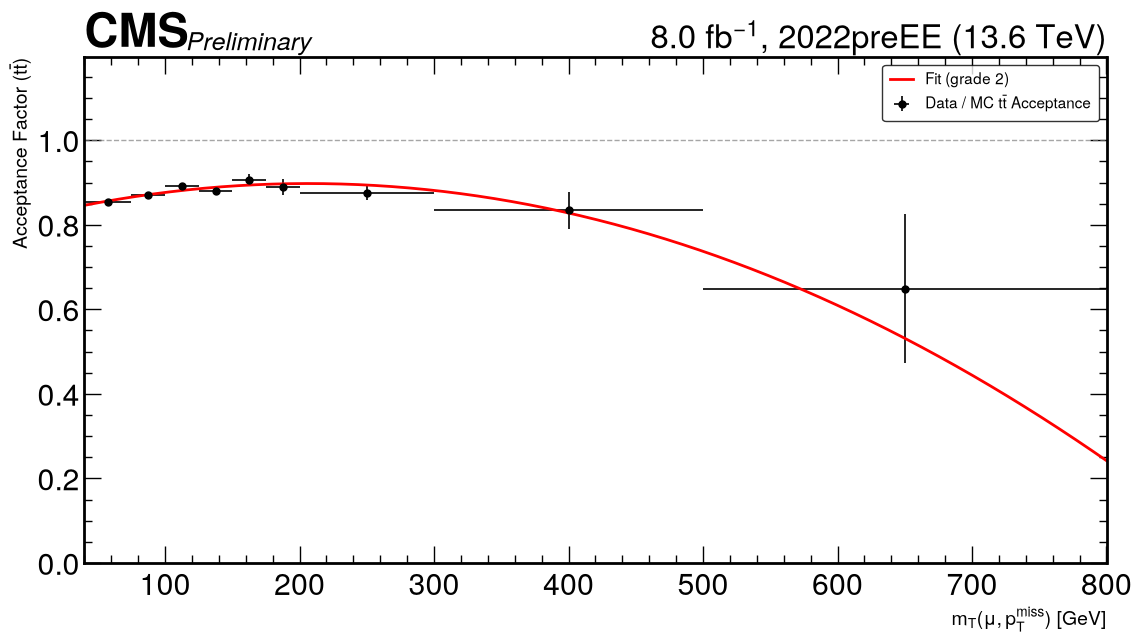

In [6]:
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
import yaml
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import f as f_dist

# --- 1. CARGA DE HISTOGRAMAS Y BKG ---
year = "2022preEE"
run_key = "2" if year.startswith("201") else "3"
energy = {"2": "13", "3": "13.6"}
out = load_hists(year, "2b1mu")


procs = ["DYJetsToLL", "SingleTop", "Diboson", "WJetsToLNu"]
mc_non_tt = accumulate([out[p]["mass"] for p in procs if p in out])
mc_tt = out["tt"]["mass"]
data = out["Data"]["mass"]

# Proyección a 1D (Masa Métrica Muón - MET)
h_data = data[{"variation": "nominal"}].project("muon_met_mass")
h_mc_non_tt = mc_non_tt[{"variation": "nominal"}].project("muon_met_mass")
h_mc_tt = mc_tt[{"variation": "nominal"}].project("muon_met_mass")

# --- 2. CÁLCULO DE ACEPTACIÓN Y PROPAGACIÓN DE INCERTIDUMBRE ---
# Resta de Data - Non-ttbar MC
D = h_data.values() - h_mc_non_tt.values()
var_D = h_data.variances() + h_mc_non_tt.variances()

# MC ttbar
M = h_mc_tt.values() + 1e-32
var_M = h_mc_tt.variances()

# Cociente y Varianza
accpt = D / M
accpt_var = (var_D / (M**2)) + ((D**2 * var_M) / (M**4))
yerr_accpt = np.sqrt(np.maximum(accpt_var, 0))

# Geometría de los Bins
edges = h_mc_tt.axes[0].edges
centers = 0.5 * (edges[:-1] + edges[1:])
widths = np.diff(edges)
xerr = widths / 2.0

# --- 3. FILTRADO Y AJUSTE POLINÓMICO OPTIMAL ---
valid_mask = (
    (M > 1e-5)
    & (yerr_accpt > 0)
    & (~np.isnan(accpt))
    & (~np.isnan(yerr_accpt))
    & (~np.isinf(accpt))
)

x_fit = centers[valid_mask]
y_fit = accpt[valid_mask]
yerr_fit = yerr_accpt[valid_mask]

# Fit usando F-test de tu función previa
best_degree, optimal_coefs, cov_matrix = find_optimal_tf_poly(
    x_fit, y_fit, yerr_fit, max_degree=5, alpha=0.05
)

# Guardar valores suavizados e inyectar al histograma final
accpt_smooth_values = np.maximum(poly_func(centers, *optimal_coefs), 1e-5)

h_accpt = h_mc_tt.copy()
h_accpt.values()[:] = accpt
h_accpt.variances()[:] = accpt_var

# --- 4. GRAFICAR RESULTADO ---
hep.style.use("CMS")
fig, ax = plt.subplots(figsize=(12, 7))

# Puntos discretos con barras de error
ax.errorbar(
    centers,
    accpt,
    xerr=xerr,
    yerr=yerr_accpt,
    fmt="o",
    color="black",
    markersize=5,
    capsize=0,
    elinewidth=1.2,
    label=r"Data / MC $t\bar{t}$ Acceptance",
)

# Curva continua ajustada
x_fine = np.linspace(edges[0], edges[-1], 300)
y_fine = np.maximum(poly_func(x_fine, *optimal_coefs), 1e-5)
ax.plot(
    x_fine,
    y_fine,
    color="red",
    linestyle="-",
    linewidth=2,
    label=f"Fit (grade {best_degree})",
)

# Estética y límites
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_ylabel(r"Acceptance Factor ($t\bar{t}$)", fontsize=14)
ax.set_xlabel(r"$m_T(\mu, p_T^{miss})$ [GeV]", fontsize=14)
ax.set_xlim(edges[0], edges[-1])

max_y = np.max(accpt[valid_mask] + yerr_accpt[valid_mask]) if len(y_fit) > 0 else 1.5
ax.set_ylim(0.0, max_y * 1.3)

ax.tick_params(direction="in", top=True, right=True)
ax.legend(loc="upper right", fontsize=11, frameon=True, edgecolor="black")

# Información CMS (Run 3 - 13.6 TeV)
with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
    luminosities = yaml.safe_load(f)

lumi_val = luminosities.get(year, 7.98) * 1e-3  # fb^-1
hep.cms.label(
    ax=ax,
    lumi=round(luminosities[year] * 1e-3, 1),
    com=energy[run_key].split()[0],
    data=True,
    year=year
)

ax.text(
    0.1, 1.00,
    r"$\mathit{Preliminary}$", 
    verticalalignment="bottom", 
    horizontalalignment="left", 
    transform=ax.transAxes, 
    fontsize=18
)

plt.tight_layout()
plt.savefig(f"ttbar_acceptance_{year}.png", dpi=300)
plt.show()

### QCD EVENTS IN SR

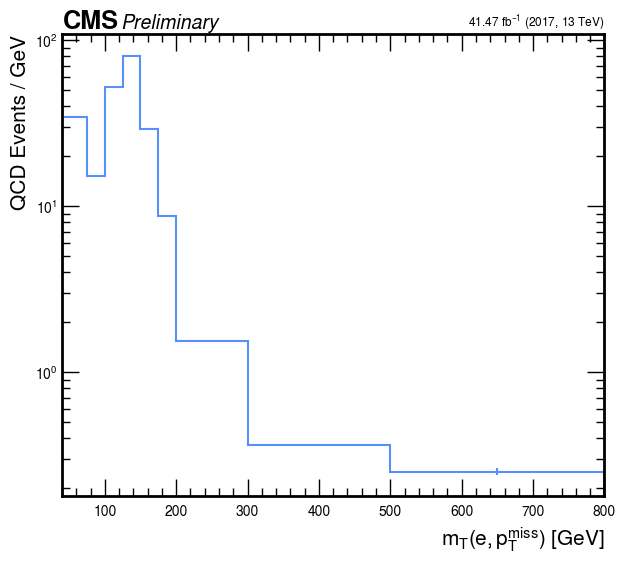

In [5]:
#######QCD STIMATION
out_qcd = load_hists("2017", "qcd_ele")
procs_qcd = ["DYJetsToLL", "SingleTop", "tt", "Diboson", "WJetsToLNu"]
mc_qcd_all = accumulate([out_qcd[p]["transverse_mass"] for p in procs_qcd if p in out_qcd])
h_qcd_base = out_qcd["Data"]["transverse_mass"] + (mc_qcd_all * -1)
variable_qcd = "electron_met_mass"
h_qcd_cr = h_qcd_base[{"variation": "nominal"}].project(variable_qcd)
h_qcd = h_qcd_cr.copy()
h_qcd.view()[:] = np.stack([
    h_qcd_cr.values() * tf, 
    h_qcd_cr.variances() * (tf**2)
], axis=-1)

#############PLOT QCD EVENTS STIMATED
def plot_cms_histogram(hist_histogram, variable):
    hep.style.use(hep.style.CMS)
    plt.rcParams.update(
        {
            "font.size": 14,
            "axes.titlesize": 14,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "lines.markersize": 4,
            "legend.fontsize": 10,
        }
    )
    h_temp = hist_histogram.project(variable)
    widths = h_temp.axes[0].widths
    h_norm = hist.Hist(h_temp.axes[0], storage=hist.storage.Weight())
    h_norm.view()[:] = np.stack([
        h_temp.values() / widths, 
        h_temp.variances() / (widths**2)
    ], axis=-1)
    fig, ax = plt.subplots(figsize=(7, 6))
    h_norm.plot1d(ax=ax)
    ax.set(ylabel="QCD Events / GeV")
    ax.set(yscale="log")
    edges = h_norm.axes[0].edges
    ax.set_xlim(edges[0], edges[-1])
    hep.cms.lumitext("41.47 fb$^{-1}$ (2017, 13 TeV)", fontsize=9, ax=ax)
    hep.cms.text("Preliminary", loc=0, ax=ax)
    return fig, ax
plot_cms_histogram(h_qcd, variable_qcd);

### INJECTION OF QCD EVENTS INTO SIGNAL REGION

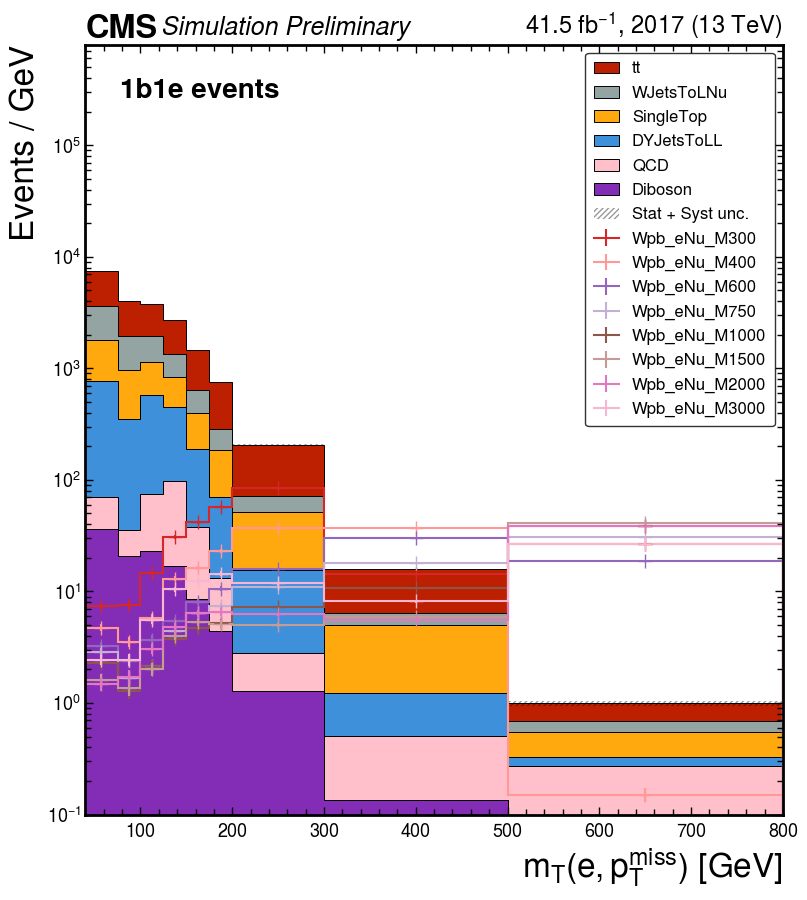

In [6]:
out_signal = load_hists("2017", "1b1e")
main_key = "mass"
variable_axis = "electron_met_mass" 
category_signal = "1b1e"
any_proc = next(p for p in out_signal.keys() if p != "Data")
h_template_full = out_signal[any_proc][main_key]
selector = {}
if "variation" in h_template_full.axes.name: selector["variation"] = "nominal"
if "category" in h_template_full.axes.name: selector["category"] = category_signal
h_template_1d = h_template_full[selector]
if variable_axis in h_template_1d.axes.name:
    h_template_1d = h_template_1d.project(variable_axis)
h_qcd_inj = hist.Hist(*h_template_1d.axes, storage=hist.storage.Weight())
h_qcd_inj.values()[:] = h_qcd.values()[:]
h_qcd_inj.variances()[:] = h_qcd.variances()[:]
axes_to_add = []
if "variation" in h_template_full.axes.name:
    axes_to_add.append(hist.axis.StrCategory(["nominal"], name="variation"))
if "category" in h_template_full.axes.name:
    axes_to_add.append(hist.axis.StrCategory([category_signal], name="category"))
if axes_to_add:
    h_final_qcd = hist.Hist(*axes_to_add, *h_qcd_inj.axes, storage=hist.storage.Weight())
    h_final_qcd.view()[:] = h_qcd_inj.view()
else:
    h_final_qcd = h_qcd_inj
out_signal["QCD"] = {main_key: h_final_qcd}
class CoffeaPlotter:
    def __init__(self, workflow, year, processed_histograms, output_dir):
        self.workflow, self.year, self.processed_histograms, self.output_dir = workflow, year, processed_histograms, output_dir
        builder = WorkflowConfigBuilder(workflow=workflow)
        config = builder.build_workflow_config()
        path = Path.cwd() / "analysis" / "postprocess"
        with open(path / "style.yaml") as f: self.style = yaml.safe_load(f)
        with open(path / "color_map.yaml") as f: cmap = yaml.safe_load(f)
        procs, _, _ = get_process_maps(config, year)
        self.color_map = {p: c for p, c in cmap.items() if p in procs and not p.startswith("Wpb")}
        self.color_map["QCD"] = "#FFC0CB" 
        self.signal_color_map = {p: c for p, c in cmap.items() if p.startswith("Wpb")}

    def collect_and_project(self, main_key, var_axis, category):
        h_info = {"mc": {"hists": [], "labels": [], "colors": []}, 
                  "signal": {"hists": [], "labels": [], "colors": []}, 
                  "data": None}
        for proc, h_dict in self.processed_histograms.items():
            h = h_dict.get(main_key)
            if h is None: continue
            sel = {}
            if "variation" in h.axes.name: sel["variation"] = "nominal"
            if "category" in h.axes.name: sel["category"] = category
            temp_h = h[sel]
            if var_axis in temp_h.axes.name:
                temp_h = temp_h.project(var_axis)
            widths = temp_h.axes[0].widths
            vals = temp_h.values() / widths
            vars = temp_h.variances() / (widths**2)
            
            h_norm = hist.Hist(temp_h.axes[0], storage=hist.storage.Weight())
            h_norm.view()[:] = np.stack([vals, vars], axis=-1)
                
            if proc == "Data":
                h_info["data"] = h_norm
            elif proc.startswith("Wpb"):
                h_info["signal"]["hists"].append(h_norm)
                h_info["signal"]["labels"].append(proc)
                h_info["signal"]["colors"].append(self.signal_color_map.get(proc, "black"))
            else:
                h_info["mc"]["hists"].append(h_norm)
                h_info["mc"]["labels"].append(proc)
                h_info["mc"]["colors"].append(self.color_map.get(proc, "gray"))
        return h_info

    def plot_histograms(self, main_key, var_axis, category, log=True):
        hep.style.use(hep.style.CMS)
        plt.rcParams.update(self.style["rcParams"])
        
        h_info = self.collect_and_project(main_key, var_axis, category)
        
        fig, ax = plt.subplots(figsize=(9, 10))
        mc_hists = h_info["mc"]["hists"]
        total_mc = accumulate(mc_hists)
        
        mc_stk_args = self.style["mc_hist_kwargs"].copy()
        mc_stk_args.pop("stack", None)
        mc_stk_args.pop("edgecolor", None)

        hep.histplot(
            mc_hists, 
            label=h_info["mc"]["labels"], 
            color=h_info["mc"]["colors"], 
            stack=True, 
            ax=ax, 
            edgecolor="black",
            **mc_stk_args
        )
        edges = total_mc.axes[0].edges
        ax.stairs(
            values=total_mc.values() + np.sqrt(total_mc.variances()),
            baseline=total_mc.values() - np.sqrt(total_mc.variances()),
            edges=edges,
            fill=True,
            color="none",
            edgecolor="black",
            linewidth=0,
            alpha=0.4,
            hatch="//////", 
            label="Stat + Syst unc."
        )
        if h_info["signal"]["hists"]:
            for h_sig, label, color in zip(h_info["signal"]["hists"], h_info["signal"]["labels"], h_info["signal"]["colors"]):
                hep.histplot(
                    h_sig,
                    label=label,
                    color=color,
                    histtype='step',
                    ax=ax,
                    linewidth=1.5
                )
                x_centers = h_sig.axes[0].centers
                y_values = h_sig.values()
                ax.plot(
                    x_centers, y_values, 
                    marker="+", color=color, linestyle="None", markersize=10
                )
        if h_info["data"]:
            hep.histplot(
                h_info["data"], 
                label="Data", 
                ax=ax, 
                histtype='errorbar',
                color="black",
                marker="o",
                markersize=6
            )
        if log:
            ax.set_yscale("log")
            ax.set_ylim(1e-1, 1e6-2*1e5)
        
        ax.set_xlim(edges[0], edges[-1])
        ax.legend(
            ncol=1, 
            fontsize=12, 
            loc="upper right", 
            frameon=True, 
            edgecolor="black",
            labelspacing=0.5
        )
        hep.cms.label("Preliminary", data=False, lumi=41.5, year=2017, ax=ax)
        
        ax.set_ylabel("Events / GeV", fontsize=24)
        ax.set_xlabel(r"$m_T(e, p_T^{miss})$ [GeV]", fontsize=24)
        ax.text(0.05, 0.93, f"{category} events", transform=ax.transAxes, fontsize=20, fontweight='bold')
        plt.show()
        plt.close()
plotter = CoffeaPlotter("1b1e", "2017", out_signal, "./plots")
plotter.plot_histograms(main_key, variable_axis, category_signal)

In [7]:
import pandas as pd
def get_background_percentages(plotter, main_key, var_axis, category):
    background_yields = {}
    for proc, h_dict in plotter.processed_histograms.items():
        if proc == "Data" or proc.startswith("Wpb"):
            continue
        h = h_dict.get(main_key)
        if h is None: continue
        sel = {"variation": "nominal"} if "variation" in h.axes.name else {}
        if "category" in h.axes.name: sel["category"] = category
        temp_h = h[sel]
        if var_axis in temp_h.axes.name:
            temp_h = temp_h.project(var_axis)
        total_events = temp_h.sum().value
        background_yields[proc] = total_events
    df = pd.DataFrame(list(background_yields.items()), columns=['Proceso', 'Eventos'])
    total_bg = df['Eventos'].sum()
    df['Porcentaje (%)'] = (df['Eventos'] / total_bg) * 100
    df = df.sort_values(by='Eventos', ascending=False).reset_index(drop=True)
    print(f"--- Composición de Background en {category} ---")
    print(f"Total Background (Events): {total_bg:.2f}\n")
    print(df.to_string(index=False, formatters={'Eventos': '{:.2f}'.format, 'Porcentaje (%)': '{:.2f}%'.format}))
    return df
df_composición = get_background_percentages(plotter, main_key, variable_axis, category_signal)

--- Composición de Background en 1b1e ---
Total Background (Events): 605726.77

   Proceso   Eventos Porcentaje (%)
        tt 315494.26         52.09%
WJetsToLNu 132031.60         21.80%
 SingleTop  88214.90         14.56%
DYJetsToLL  60564.71         10.00%
       QCD   6155.43          1.02%
   Diboson   3265.86          0.54%
